In [185]:
import pandas as pd
import matplotlib.pyplot as plt

In [186]:
laps_df = pd.read_csv('data/all_laps.csv', low_memory=False)
throttle_df = pd.read_csv('data/throttle_pct.csv', low_memory=False)
results_df = pd.read_csv('data/all_results.csv', low_memory=False)
weather_df = pd.read_csv('data/all_weather.csv', low_memory=False)

### check api data for duplicates

In [187]:
print(f"duplicates in lap data:{laps_df.duplicated().sum()}")
print(f"duplicates in throttle data:{throttle_df.duplicated().sum()}")
print(f"duplicates in results data:{results_df.duplicated().sum()}")
print(f"duplicates in weather data:{weather_df.duplicated().sum()}")

duplicates in lap data:0
duplicates in throttle data:0
duplicates in results data:0
duplicates in weather data:0


### check column names

In [188]:
laps_df.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'EventName', 'EventDate'],
      dtype='object')

In [189]:
results_df.columns

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps',
       'EventName', 'EventDate'],
      dtype='object')

In [190]:
weather_df.columns

Index(['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp',
       'WindDirection', 'WindSpeed', 'EventName', 'EventDate'],
      dtype='object')

### combine data

In [191]:
team_df = pd.read_csv('data/team_names_2014.csv', low_memory=False)
team_df = team_df[['year', 'team', 'engine', 'works']]

In [192]:
throttle_df = throttle_df[['Year', 'EventName', 'FullThrottlePct']]
weather_df = weather_df[['EventDate', 'EventName', 'Time', 'Rainfall']]
laps_df = laps_df[['EventDate', 'EventName', 'Driver', 'Time','LapTime']]
results_df = results_df[['EventDate', 'EventName', 'DriverId', 'Abbreviation', 'TeamName', 'Q1']]

In [193]:
(weather_df.groupby(["EventName", "EventDate"])["Rainfall"].nunique()
           .reset_index(name="distinct_count")
           .query("distinct_count != 1").head())

,EventName,EventDate,distinct_count
12,Australian Grand Prix,2023-04-02,2
13,Australian Grand Prix,2024-03-24,2
16,Austrian Grand Prix,2018-07-01,2
24,Azerbaijan Grand Prix,2018-04-29,2
30,Azerbaijan Grand Prix,2025-09-21,2


In [194]:
laps_df["Time"] = pd.to_timedelta(laps_df["Time"])
weather_df["Time"] = pd.to_timedelta(weather_df["Time"])

laps_weather_df = pd.merge_asof(laps_df.sort_values("Time"),
                                weather_df.sort_values("Time"),
                                on="Time",
                                by=["EventName", "EventDate"],
                                direction="nearest")

In [195]:
int(laps_weather_df["Rainfall"].isna().sum())

0

In [196]:
results_df["Q1"] = pd.to_timedelta(results_df["Q1"])
laps_weather_df["LapTime"] = pd.to_timedelta(laps_weather_df["LapTime"])

merged_df = results_df.merge(laps_weather_df, 
                             left_on=["EventName", "EventDate", "Abbreviation", "Q1"],
                             right_on=["EventName", "EventDate", "Driver", "LapTime"],
                             how="left")

merged_df["Year"] = pd.to_datetime(merged_df["EventDate"]).dt.year
merged_df["Q1_time"] = pd.to_timedelta(merged_df["Q1"]).dt.total_seconds()
merged_df = merged_df[['Year', 'EventName', 'DriverId', 'TeamName', 'Q1_time', 'Rainfall']]

In [197]:
final_df = (merged_df.merge(throttle_df, left_on=["Year", "EventName"],
                            right_on=["Year", "EventName"], how="left")
                     .merge(team_df, left_on=["Year", "TeamName"], right_on=["year", "team"],
                            how="left"))

final_df = final_df[["Year","EventName", "FullThrottlePct", "Rainfall", "DriverId", 
                     "TeamName", "engine", "works", "Q1_time"]]

final_df = final_df.drop_duplicates()
final_df = final_df.dropna(subset=["DriverId", "Q1_time"])

In [198]:
final_df.head()

,Year,EventName,FullThrottlePct,Rainfall,DriverId,TeamName,engine,works,Q1_time
0,2025,Singapore Grand Prix,51.114413,False,russell,Mercedes,Mercedes,1.0,89.928
1,2025,Singapore Grand Prix,51.114413,False,max_verstappen,Red Bull Racing,NaN,NaN,90.028
2,2025,Singapore Grand Prix,51.114413,False,piastri,McLaren,Mercedes,0.0,90.313
3,2025,Singapore Grand Prix,51.114413,False,antonelli,Mercedes,Mercedes,1.0,90.036
4,2025,Singapore Grand Prix,51.114413,False,norris,McLaren,Mercedes,0.0,89.932


In [199]:
final_df.to_csv("data/modeling_table.csv", index=False)

In [200]:
final_df.describe()

,Year,FullThrottlePct,works,Q1_time
count,3611.000000,3611.000000,2479.00000,3611.000000
mean,2021.718914,61.027818,0.48447,85.331323
std,2.323295,8.748785,0.49986,12.404470
min,2018.000000,32.859400,0.00000,53.904000
25%,2020.000000,56.382979,0.00000,76.548000
50%,2022.000000,62.146051,0.00000,85.177000
75%,2024.000000,67.159763,1.00000,93.032000
max,2026.000000,76.546763,1.00000,141.611000


In [201]:
(final_df.isna().sum().rename("null_count")
         .reset_index().rename(columns={"index": "column"})
         .sort_values("null_count", ascending=False))

,column,null_count
6,engine,1132
7,works,1132
3,Rainfall,4
0,Year,0
1,EventName,0
2,FullThrottlePct,0
4,DriverId,0
5,TeamName,0
8,Q1_time,0


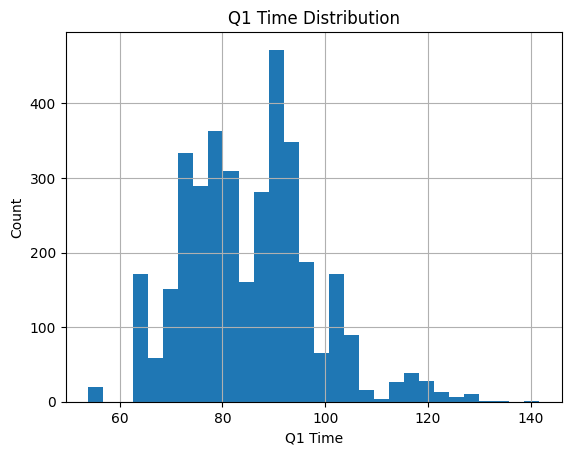

In [202]:
final_df["Q1_time"].hist(bins=30)
plt.title("Q1 Time Distribution")
plt.xlabel("Q1 Time")
plt.ylabel("Count")
plt.show()

In [203]:
final_df.groupby("Rainfall")["Q1_time"].describe()

,count,mean,std,min,25%,50%,75%,max
Rainfall,,,,,,,,
False,3413.0,84.987744,12.200540,53.904,76.12200,84.7380,92.804,130.017
True,194.0,91.453108,14.258933,76.666,78.89825,89.0965,95.628,141.611
